<a href="https://colab.research.google.com/github/NAZikra38/B.Sc-Senior-project/blob/main/SENIOR_PROJECT_CODES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## V_11 Element of the matrix


import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

# Your derived expression
analytic = V0 * (delta/a + np.sin(np.pi*delta/a) / np.pi)

# Direct numerical integration to verify
def integrand(x):
    return (V0/a) * np.cos(np.pi*x/(2*a))**2

numerical, _ = integrate.quad(integrand, -delta, delta)

print(f"Analytic:  {analytic:.10f}")
print(f"Numerical: {numerical:.10f}")
print(f"Match: {abs(analytic-numerical) < 1e-8}")

Analytic:  0.3870978568
Numerical: 0.3870978568
Match: True


In [ ]:
## V_22 Element of the matrix

import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

# Fill in your derived expression here
analytic = V0 * (delta/a - np.sin(2*np.pi*delta/a)/(2*np.pi))

def integrand(x):
    return (V0/a) * np.sin(np.pi*x/a)**2

numerical, _ = integrate.quad(integrand, -delta, delta)

print(f"Analytic:  {analytic:.10f}")
print(f"Numerical: {numerical:.10f}")
print(f"Match: {abs(analytic-numerical) < 1e-8}")

Analytic:  0.0486346543
Numerical: 0.0486346543
Match: True


In [1]:
## V_12 Element of the matrix

import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

def integrand(x):
    return (V0/a) * np.cos(np.pi*x/(2*a)) * np.sin(np.pi*x/a)

numerical, _ = integrate.quad(integrand, -delta, delta)

print(f"V12 numerical: {numerical:.10f}")
print(f"Is zero: {abs(numerical) < 1e-10}")

V12 numerical: 0.0000000000
Is zero: True


In [2]:
## V_13 Element of the matrix


import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

def integrand(x):
    return (V0/a) * np.cos(np.pi*x/(2*a)) * np.cos(3*np.pi*x/(2*a))

numerical, _ = integrate.quad(integrand, -delta, delta)
print(f"V13 numerical: {numerical:.10f}")

V13 numerical: 0.3384632025


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
## V_15 Element of the matrix

import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

# Your answer (incorrect - this is V55)
your_answer = V0 * (delta/a + np.sin(5*np.pi*delta/a)/(5*np.pi))

# Correct answer for V15
correct_answer = (V0/(2*np.pi))*np.sin(2*np.pi*delta/a) + (V0/(3*np.pi))*np.sin(3*np.pi*delta/a)

# Numerical check
def integrand(x):
    return (V0/a) * np.cos(np.pi*x/(2*a)) * np.cos(5*np.pi*x/(2*a))

numerical, _ = integrate.quad(integrand, -delta, delta)

print(f"Your answer:    {your_answer:.10f}")
print(f"Correct answer: {correct_answer:.10f}")
print(f"Numerical:      {numerical:.10f}")
print(f"Correct match:  {abs(correct_answer - numerical) < 1e-8}")

Your answer:    0.2000000000
Correct answer: 0.2522755762
Numerical:      0.2522755762
Correct match:  True


In [4]:
## V_33 Element of the matrix

import numpy as np
from scipy import integrate

a = 1.0
delta = 0.2
V0 = 1.0

# Your derived expression
analytic = V0 * (delta/a + np.sin(3*np.pi*delta/a)/(3*np.pi))

# Numerical check
def integrand(x):
    return (V0/a) * np.cos(3*np.pi*x/(2*a))**2

numerical, _ = integrate.quad(integrand, -delta, delta)

print(f"Analytic:  {analytic:.10f}")
print(f"Numerical: {numerical:.10f}")
print(f"Match: {abs(analytic-numerical) < 1e-8}")



Analytic:  0.3009102305
Numerical: 0.3009102305
Match: True


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/first_order_energy_shifts.pdf'

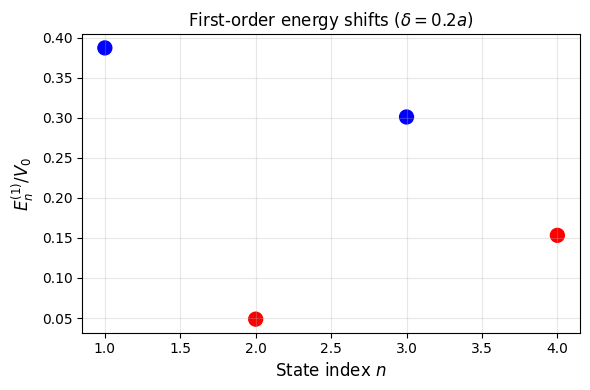

In [5]:
## First order energy shift


import numpy as np
import matplotlib.pyplot as plt

a = 1.0
delta = 0.2
V0 = 1.0

n_values = np.array([1, 2, 3, 4])
E1 = [V0*(delta/a + np.sin(np.pi*delta/a)/np.pi),
      V0*(delta/a - np.sin(2*np.pi*delta/a)/(2*np.pi)),
      V0*(delta/a + np.sin(3*np.pi*delta/a)/(3*np.pi)),
      V0*(delta/a - np.sin(4*np.pi*delta/a)/(4*np.pi))]

plt.figure(figsize=(6,4))
plt.scatter(n_values, np.array(E1)/V0, s=100, c=['blue','red','blue','red'])
plt.xlabel(r'State index $n$', fontsize=12)
plt.ylabel(r'$E_n^{(1)}/V_0$', fontsize=12)
plt.title(r'First-order energy shifts ($\delta = 0.2a$)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/first_order_energy_shifts.pdf')
plt.show()

In [ ]:
# [E_1^(2)] computes V_{1m}​ for any odd m using the product-to-sum method.


import numpy as np

def compute_V1m(m, V0, delta, a):
    """
    Compute V_1m for odd m using product-to-sum identity.
    V_1m = integral of cos(pi*x/2a) * cos(m*pi*x/2a) over [-delta, +delta]

    Product-to-sum gives:
    cos(A)*cos(B) = 1/2*cos(A-B) + 1/2*cos(A+B)
    with A = pi*x/2a, B = m*pi*x/2a

    A - B = (1-m)*pi*x/2a
    A + B = (1+m)*pi*x/2a
    """
    if m % 2 == 0:
        return 0.0  # Even m couples to odd states, should be zero

    # Coefficients for the two cosine terms
    k1 = (m - 1) * np.pi / (2 * a)
    k2 = (m + 1) * np.pi / (2 * a)

    # Integral of cos(k*x) from -delta to +delta is (2/k)*sin(k*delta)
    if k1 == 0:
        # Special case: m=1 gives k1=0, integral is just 2*delta
        term1 = 2 * delta
    else:
        term1 = (2 / k1) * np.sin(k1 * delta)

    term2 = (2 / k2) * np.sin(k2 * delta)

    # V_1m = (V0/2a) * (term1 + term2)
    V1m = (V0 / (2 * a)) * (term1 + term2)

    return V1m


def compute_E1_second_order(V0, delta, a, E1, m_max=13):
    """
    Compute second-order energy correction to ground state.
    E1^(2) = sum over odd m>=3 of |V_1m|^2 / (E1 - Em)
    where Em = m^2 * E1
    """
    E1_second = 0.0
    contributions = []

    for m in range(3, m_max + 1, 2):  # Odd values: 3, 5, 7, ...
        V1m = compute_V1m(m, V0, delta, a)
        Em = m**2 * E1
        denominator = E1 - Em

        contribution = V1m**2 / denominator
        E1_second += contribution

        contributions.append({
            'm': m,
            'V1m': V1m,
            'contribution': contribution,
            'cumulative': E1_second
        })

    return E1_second, contributions


# Parameters
a = 1.0
delta = 0.2 * a
V0 = 1.0
E1 = (np.pi**2) / (8 * a**2)  # Ground state energy in natural units

# Compute E1^(2)
E1_2nd, contribs = compute_E1_second_order(V0, delta, a, E1, m_max=13)

print("Second-order energy correction to ground state:")
print(f"E1^(2) = {E1_2nd:.10f}")
print(f"E1^(2)/E1 = {E1_2nd/E1:.10f}")
print("\nContributions by state:")
print(f"{'m':<5} {'V_1m':<15} {'Contribution':<15} {'Cumulative':<15}")
print("-" * 55)
for c in contribs:
    print(f"{c['m']:<5} {c['V1m']:<15.6e} {c['contribution']:<15.6e} {c['cumulative']:<15.6e}")

# Check convergence: compare m_max=11 vs m_max=13
E1_2nd_11, _ = compute_E1_second_order(V0, delta, a, E1, m_max=11)
E1_2nd_13, _ = compute_E1_second_order(V0, delta, a, E1, m_max=13)

print(f"\nConvergence check:")
print(f"Sum to m=11: {E1_2nd_11:.10f}")
print(f"Sum to m=13: {E1_2nd_13:.10f}")
print(f"Difference:  {abs(E1_2nd_13 - E1_2nd_11):.10e}")
print(f"Relative:    {abs(E1_2nd_13 - E1_2nd_11) / abs(E1_2nd_13) * 100:.3f}%")




In [ ]:
# [E_2^(2)] computes V_{2m}​ for any odd m using the product-to-sum method.

import numpy as np

def compute_V2m(m, V0, delta, a):
    """
    Compute V_2m for even m using product-to-sum identity.
    V_2m = integral of sin(pi*x/a) * sin(m*pi*x/a) over [-delta, +delta]

    Product-to-sum gives:
    sin(A)*sin(B) = 1/2*cos(A-B) - 1/2*cos(A+B)
    with A = pi*x/a, B = m*pi*x/a

    A - B = (1-m)*pi*x/a
    A + B = (1+m)*pi*x/a
    """
    if m % 2 == 1:
        return 0.0  # Odd m couples to even states, should be zero

    # Coefficients for the two cosine terms
    k1 = (m - 1) * np.pi / a
    k2 = (m + 1) * np.pi / a

    # sin*sin product-to-sum: 1/2*cos(A-B) - 1/2*cos(A+B)
    # Integral of cos(k*x) from -delta to +delta is (2/k)*sin(k*delta)

    term1 = (2 / k1) * np.sin(k1 * delta)
    term2 = (2 / k2) * np.sin(k2 * delta)

    # V_2m = (V0/2a) * (term1 - term2)  [note the minus sign from sin*sin formula]
    V2m = (V0 / (2 * a)) * (term1 - term2)

    return V2m


def compute_E2_second_order(V0, delta, a, E1, m_max=14):
    """
    Compute second-order energy correction to first excited state.
    E2^(2) = sum over even m>=4 of |V_2m|^2 / (E2 - Em)
    where E2 = 4*E1, Em = m^2 * E1
    """
    E2 = 4 * E1
    E2_second = 0.0
    contributions = []

    for m in range(4, m_max + 1, 2):  # Even values: 4, 6, 8, ...
        V2m = compute_V2m(m, V0, delta, a)
        Em = m**2 * E1
        denominator = E2 - Em

        contribution = V2m**2 / denominator
        E2_second += contribution

        contributions.append({
            'm': m,
            'V2m': V2m,
            'Em/E1': m**2,
            'denominator/E1': (4 - m**2),
            'contribution': contribution,
            'cumulative': E2_second
        })

    return E2_second, contributions


# Parameters
a = 1.0
delta = 0.2 * a
V0 = 1.0
E1 = (np.pi**2) / (8 * a**2)

# Compute E2^(2)
E2_2nd, contribs = compute_E2_second_order(V0, delta, a, E1, m_max=14)

print("Second-order energy correction to first excited state:")
print(f"E2^(2) = {E2_2nd:.10f}")
print(f"E2^(2)/E1 = {E2_2nd/E1:.10f}")
print(f"E2^(2)/E2 = {E2_2nd/(4*E1):.10f}")
print("\nContributions by state:")
print(f"{'m':<5} {'V_2m':<15} {'Em/E1':<10} {'(E2-Em)/E1':<15} {'Contribution':<15} {'Cumulative':<15}")
print("-" * 90)
for c in contribs:
    print(f"{c['m']:<5} {c['V2m']:<15.6e} {c['Em/E1']:<10.1f} {c['denominator/E1']:<15.1f} {c['contribution']:<15.6e} {c['cumulative']:<15.6e}")

# Check convergence
E2_2nd_12, _ = compute_E2_second_order(V0, delta, a, E1, m_max=12)
E2_2nd_14, _ = compute_E2_second_order(V0, delta, a, E1, m_max=14)

print(f"\nConvergence check:")
print(f"Sum to m=12: {E2_2nd_12:.10f}")
print(f"Sum to m=14: {E2_2nd_14:.10f}")
print(f"Difference:  {abs(E2_2nd_14 - E2_2nd_12):.10e}")
print(f"Relative:    {abs(E2_2nd_14 - E2_2nd_12) / abs(E2_2nd_14) * 100:.3f}%")

# Compare with E1^(2)
print(f"\nComparison:")
print(f"E1^(2)/E1 = -0.0114941389  (ground state)")
print(f"E2^(2)/E1 = {E2_2nd/E1:.10f}  (first excited state)")


In [ ]:
"""
Compute second-order energy corrections E_n^(2) for the symmetric infinite well
with a rectangular barrier perturbation.

This code implements the second-order perturbation theory formula:
    E_n^(2) = sum_{m != n} |V_nm|^2 / (E_n - E_m)

Parity selection rule reduces the sum to same-parity states only.
"""

import numpy as np
import pandas as pd


def compute_V1m(m, V0, delta, a):
    """
    Compute V_1m for odd m (even-even coupling).
    Uses product-to-sum identity for cos*cos.

    V_1m = (V0/a) * integral of cos(pi*x/2a) * cos(m*pi*x/2a) over [-delta, +delta]
    """
    if m % 2 == 0:
        return 0.0  # Parity selection: even state cannot couple to odd state

    # Product-to-sum: cos(A)*cos(B) = 1/2*cos(A-B) + 1/2*cos(A+B)
    # A = pi*x/2a, B = m*pi*x/2a
    # A - B = (1-m)*pi*x/2a, A + B = (1+m)*pi*x/2a

    k1 = (m - 1) * np.pi / (2 * a)
    k2 = (m + 1) * np.pi / (2 * a)

    # Special case: m=1 gives k1=0
    if k1 == 0:
        term1 = 2 * delta
    else:
        term1 = (2 / k1) * np.sin(k1 * delta)

    term2 = (2 / k2) * np.sin(k2 * delta)

    V1m = (V0 / (2 * a)) * (term1 + term2)
    return V1m


def compute_V2m(m, V0, delta, a):
    """
    Compute V_2m for even m (odd-odd coupling).
    Uses product-to-sum identity for sin*sin.

    V_2m = (V0/a) * integral of sin(pi*x/a) * sin(m*pi*x/a) over [-delta, +delta]
    """
    if m % 2 == 1:
        return 0.0  # Parity selection: odd state cannot couple to even state

    # Product-to-sum: sin(A)*sin(B) = 1/2*cos(A-B) - 1/2*cos(A+B)
    # Note the minus sign!
    # A = pi*x/a, B = m*pi*x/a
    # A - B = (1-m)*pi*x/a, A + B = (1+m)*pi*x/a

    k1 = (m - 1) * np.pi / a
    k2 = (m + 1) * np.pi / a

    term1 = (2 / k1) * np.sin(k1 * delta)
    term2 = (2 / k2) * np.sin(k2 * delta)

    V2m = (V0 / (2 * a)) * (term1 - term2)  # Note minus sign
    return V2m


def compute_E1_second_order(V0, delta, a, E1, m_max=13):
    """
    Compute E_1^(2) via sum over even states m = 3, 5, 7, ...
    """
    E1_second = 0.0
    contributions = []

    for m in range(3, m_max + 1, 2):
        V1m = compute_V1m(m, V0, delta, a)
        Em = m**2 * E1
        denominator = E1 - Em

        contribution = V1m**2 / denominator
        E1_second += contribution

        contributions.append({
            'm': m,
            'V_1m': V1m,
            'E_m/E_1': m**2,
            'contribution': contribution,
            'cumulative': E1_second
        })

    return E1_second, contributions


def compute_E2_second_order(V0, delta, a, E1, m_max=14):
    """
    Compute E_2^(2) via sum over odd states m = 4, 6, 8, ...
    E_2 = 4*E_1
    """
    E2 = 4 * E1
    E2_second = 0.0
    contributions = []

    for m in range(4, m_max + 1, 2):
        V2m = compute_V2m(m, V0, delta, a)
        Em = m**2 * E1
        denominator = E2 - Em

        contribution = V2m**2 / denominator
        E2_second += contribution

        contributions.append({
            'm': m,
            'V_2m': V2m,
            'E_m/E_1': m**2,
            'contribution': contribution,
            'cumulative': E2_second
        })

    return E2_second, contributions


def main():
    # Parameters
    a = 1.0
    delta = 0.2 * a
    V0 = 1.0
    E1 = (np.pi**2) / (8 * a**2)  # Ground state energy

    print("="*80)
    print("SECOND-ORDER ENERGY CORRECTIONS")
    print(f"Parameters: a = {a}, delta = {delta}, V0 = {V0}")
    print(f"Ground state energy: E1 = {E1:.6f}")
    print("="*80)

    # Compute E1^(2)
    print("\n[1] GROUND STATE: E_1^(2)")
    print("-"*80)
    E1_2nd, contribs_1 = compute_E1_second_order(V0, delta, a, E1, m_max=13)

    print(f"E_1^(2) = {E1_2nd:.10f}")
    print(f"E_1^(2)/E_1 = {E1_2nd/E1:.10f}")
    print(f"\nDominant contributions:")

    df1 = pd.DataFrame(contribs_1[:5])  # Show first 5 terms
    print(df1.to_string(index=False))

    # Compute E2^(2)
    print("\n"+"="*80)
    print("[2] FIRST EXCITED STATE: E_2^(2)")
    print("-"*80)
    E2_2nd, contribs_2 = compute_E2_second_order(V0, delta, a, E1, m_max=14)

    print(f"E_2^(2) = {E2_2nd:.10f}")
    print(f"E_2^(2)/E_1 = {E2_2nd/E1:.10f}")
    print(f"E_2^(2)/E_2 = {E2_2nd/(4*E1):.10f}")
    print(f"\nDominant contributions:")

    df2 = pd.DataFrame(contribs_2[:4])  # Show first 4 terms
    print(df2.to_string(index=False))

    # Summary comparison
    print("\n"+"="*80)
    print("SUMMARY COMPARISON")
    print("-"*80)
    print(f"{'State':<10} {'E^(1)/E1':<15} {'E^(2)/E1':<15} {'Ratio %':<15}")
    print("-"*80)

    # First-order results from Section 3.3
    E1_first = V0 * (delta/a + np.sin(np.pi*delta/a) / np.pi)
    E2_first = V0 * (delta/a - np.sin(2*np.pi*delta/a) / (2*np.pi))

    ratio1 = abs(E1_2nd / E1_first) * 100
    ratio2 = abs(E2_2nd / E2_first) * 100

    print(f"{'psi_1':<10} {E1_first/E1:<15.6f} {E1_2nd/E1:<15.6f} {ratio1:<15.2f}")
    print(f"{'psi_2':<10} {E2_first/E1:<15.6f} {E2_2nd/E1:<15.6f} {ratio2:<15.2f}")
    print("-"*80)
    print(f"\nE_1^(2) is {abs(E1_2nd/E2_2nd):.1f}x larger than E_2^(2) (node protection effect)")
    print("\nSecond-order corrections are {:.1f}% and {:.1f}% of first-order".format(ratio1, ratio2))
    print("Perturbation theory is valid in this regime.")
    print("="*80)


if __name__ == "__main__":
    main()

In [ ]:
"""
Compute first-order mixing coefficients for perturbed eigenstates.

The first-order correction to the wavefunction is:
    psi_n^(1) = sum_{m != n} c_{nm}^(1) * psi_m^(0)
where
    c_{nm}^(1) = V_nm / (E_n - E_m)
"""

import numpy as np
import pandas as pd


def compute_V1m(m, V0, delta, a):
    """
    Compute V_1m for odd m (even-even coupling).
    Same function from Section 3.4.
    """
    if m % 2 == 0:
        return 0.0

    k1 = (m - 1) * np.pi / (2 * a)
    k2 = (m + 1) * np.pi / (2 * a)

    if k1 == 0:
        term1 = 2 * delta
    else:
        term1 = (2 / k1) * np.sin(k1 * delta)

    term2 = (2 / k2) * np.sin(k2 * delta)

    V1m = (V0 / (2 * a)) * (term1 + term2)
    return V1m


def compute_V2m(m, V0, delta, a):
    """
    Compute V_2m for even m (odd-odd coupling).
    Same function from Section 3.4.
    """
    if m % 2 == 1:
        return 0.0

    k1 = (m - 1) * np.pi / a
    k2 = (m + 1) * np.pi / a

    term1 = (2 / k1) * np.sin(k1 * delta)
    term2 = (2 / k2) * np.sin(k2 * delta)

    V2m = (V0 / (2 * a)) * (term1 - term2)
    return V2m


def compute_psi1_mixing_coefficients(V0, delta, a, E1, m_max=13):
    """
    Compute first-order mixing coefficients for ground state psi_1.

    c_{1m}^(1) = V_{1m} / (E_1 - E_m)

    Only even states (m = 3, 5, 7, ...) contribute due to parity.
    """
    coefficients = []

    for m in range(3, m_max + 1, 2):
        V1m = compute_V1m(m, V0, delta, a)
        Em = m**2 * E1

        c_1m = V1m / (E1 - Em)

        coefficients.append({
            'm': m,
            'V_1m': V1m,
            'E_m/E_1': m**2,
            'c_1m': c_1m,
            '|c_1m|': abs(c_1m)
        })

    return coefficients


def compute_psi2_mixing_coefficients(V0, delta, a, E1, m_max=14):
    """
    Compute first-order mixing coefficients for first excited state psi_2.

    c_{2m}^(1) = V_{2m} / (E_2 - E_m)

    Only odd states (m = 4, 6, 8, ...) contribute due to parity.
    """
    E2 = 4 * E1
    coefficients = []

    for m in range(4, m_max + 1, 2):
        V2m = compute_V2m(m, V0, delta, a)
        Em = m**2 * E1

        c_2m = V2m / (E2 - Em)

        coefficients.append({
            'm': m,
            'V_2m': V2m,
            'E_m/E_1': m**2,
            'c_2m': c_2m,
            '|c_2m|': abs(c_2m)
        })

    return coefficients


def main():
    # Parameters
    a = 1.0
    delta = 0.2 * a
    V0 = 1.0
    E1 = (np.pi**2) / (8 * a**2)

    print("="*80)
    print("FIRST-ORDER MIXING COEFFICIENTS FOR PERTURBED EIGENSTATES")
    print(f"Parameters: a = {a}, delta = {delta}, V0 = {V0}")
    print(f"Ground state energy: E1 = {E1:.6f}")
    print("="*80)

    # Ground state mixing coefficients
    print("\n[1] GROUND STATE PSI_1: First-order mixing")
    print("-"*80)
    print("psi_1^(1) = sum_m c_{1m}^(1) * psi_m^(0)")
    print("where m = 3, 5, 7, ... (even parity states only)")
    print("-"*80)

    coeffs_1 = compute_psi1_mixing_coefficients(V0, delta, a, E1, m_max=13)
    df1 = pd.DataFrame(coeffs_1)
    print(df1.to_string(index=False))

    # Analyze dominant contributions
    total_weight_1 = sum(abs(c['c_1m']) for c in coeffs_1)
    dominant_1 = coeffs_1[0]  # m=3

    print(f"\nDominant contribution: psi_3 with c_13 = {dominant_1['c_1m']:.6f}")
    print(f"Relative weight of psi_3: {abs(dominant_1['c_1m'])/total_weight_1 * 100:.1f}%")

    # First excited state mixing coefficients
    print("\n" + "="*80)
    print("[2] FIRST EXCITED STATE PSI_2: First-order mixing")
    print("-"*80)
    print("psi_2^(1) = sum_m c_{2m}^(1) * psi_m^(0)")
    print("where m = 4, 6, 8, ... (odd parity states only)")
    print("-"*80)

    coeffs_2 = compute_psi2_mixing_coefficients(V0, delta, a, E1, m_max=14)
    df2 = pd.DataFrame(coeffs_2)
    print(df2.to_string(index=False))

    # Analyze dominant contributions
    total_weight_2 = sum(abs(c['c_2m']) for c in coeffs_2)
    dominant_2 = coeffs_2[0]  # m=4

    print(f"\nDominant contribution: psi_4 with c_24 = {dominant_2['c_2m']:.6f}")
    print(f"Relative weight of psi_4: {abs(dominant_2['c_2m'])/total_weight_2 * 100:.1f}%")

    # Comparison
    print("\n" + "="*80)
    print("COMPARISON: How strongly does the barrier mix states?")
    print("-"*80)
    print(f"Ground state (psi_1):       |c_13| = {abs(dominant_1['c_1m']):.6f}")
    print(f"First excited (psi_2):      |c_24| = {abs(dominant_2['c_2m']):.6f}")
    print(f"Ratio |c_13| / |c_24| = {abs(dominant_1['c_1m']) / abs(dominant_2['c_2m']):.1f}")
    print("\nThe barrier distorts psi_1 much more strongly than psi_2 (node protection).")
    print("="*80)


if __name__ == "__main__":
    main()

CHAPTER 4

In [ ]:
from ast import Import
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
from scipy.linalg import solve_banded


def make_grid(N=1024, a=1.0):
    x  = np.linspace(-a, a, N)
    dx = x[1] - x[0]
    return x, dx
def unperturbed_eigenstates(x, n_max=6, a=1.0):
    """
    Eigenstates of the unperturbed infinite square well [-a, +a].
      n odd  -> psi_n = (1/sqrt(a)) * cos(n*pi*x / (2a))   [even parity]
      n even -> psi_n = (1/sqrt(a)) * sin(n*pi*x / (2a))   [odd  parity]
    E_n = n^2 E1  (in units of E1)
    """
    psi = np.zeros((n_max, len(x)))
    E   = np.zeros(n_max)
    for idx, n in enumerate(range(1, n_max + 1)):
        if n % 2 == 1:
            psi[idx] = np.cos(n * np.pi * x / (2.0 * a)) / np.sqrt(a)
        else:
            psi[idx] = np.sin(n * np.pi * x / (2.0 * a)) / np.sqrt(a)
        E[idx] = float(n ** 2)
    return psi, E

def barrier_spatial(x, delta=0.2):
    """B(x) = Theta(x+delta) - Theta(x-delta) = 1 if |x| < delta, else 0."""
    return np.where(np.abs(x) < delta, 1.0, 0.0)
def V0_sudden(t, V0_max=1.0, **_):
    return V0_max if t >= 0.0 else 0.0

def V0_exponential(t, V0_max=1.0, tau=1.0, **_):
    if t < 0.0:
        return 0.0
    return V0_max * (1.0 - np.exp(-t / tau))

def V0_linear(t, V0_max=1.0, tau=1.0, **_):
    if t < 0.0:
        return 0.0
    return V0_max * min(t / tau, 1.0)

SCENARIO_FUNCS = {
    "sudden"     : V0_sudden,
    "exponential": V0_exponential,
    "linear"     : V0_linear,
}

def build_kinetic_diagonals(N, dx):
    """
    In units where E1=1, a=1, hbar=1:
      hbar^2/(2m) = 4/pi^2
    """
    hbar2_over_2m = 4.0 / (np.pi ** 2)
    c = hbar2_over_2m / dx ** 2

    main = np.full(N,  2.0 * c)
    off  = np.full(N, -1.0 * c)

    # Dirichlet BC rows
    main[0]   = 1.0; off[1]   = 0.0
    main[N-1] = 1.0; off[N-2] = 0.0

    return main, off


def apply_H(Psi, main_T, off_T, V_diag):
    """Return H|Psi> for tridiagonal H = T + V."""
    HPsi       = (main_T + V_diag) * Psi
    HPsi[1:]  += off_T[1:]  * Psi[:-1]
    HPsi[:-1] += off_T[:-1] * Psi[1:]
    return HPsi


def make_banded(main_T, off_T, V_diag, dt, sign):
    """
    Assemble banded matrix A = I + sign*(i*dt/2)*H
    in scipy (3,N) banded format.
    """
    alpha  = sign * 0.5j * dt
    A_main = 1.0 + alpha * (main_T + V_diag)
    A_off  = alpha * off_T

    ab        = np.zeros((3, len(main_T)), dtype=complex)
    ab[0, 1:] = A_off[:-1]    # upper diagonal
    ab[1, :]  = A_main         # main  diagonal
    ab[2, :-1]= A_off[1:]     # lower diagonal
    return ab


# ─────────────────────────────────────────────────────────────────────────────
# 5.  INITIAL STATE
# ─────────────────────────────────────────────────────────────────────────────

def initial_state(x, alpha=0, a=1.0):
    """
    alpha=0 -> psi_1  (ground state,     peaks at x=0)
    alpha=1 -> psi_2  (first excited,    node  at x=0)
    """
    psi, _ = unperturbed_eigenstates(x, n_max=2, a=a)
    state  = (1.0 - alpha) * psi[0] + alpha * psi[1]
    norm   = np.sqrt(np.trapezoid(np.abs(state)**2, x))
    return (state / norm).astype(complex)


# ─────────────────────────────────────────────────────────────────────────────
# 6.  OBSERVABLES
# ─────────────────────────────────────────────────────────────────────────────

def compute_populations(Psi, eigenstates, dx):
    """Return |<psi_n|Psi>|^2 for n=1..n_max via trapezoidal rule."""
    c = dx * np.dot(eigenstates, Psi)
    return np.abs(c) ** 2

def compute_norm(Psi, dx):
    return dx * np.sum(np.abs(Psi) ** 2)

def compute_energy(Psi, main_T, off_T, V_diag, dx):
    HPsi = apply_H(Psi, main_T, off_T, V_diag)
    return dx * np.real(np.dot(np.conj(Psi), HPsi))


# ─────────────────────────────────────────────────────────────────────────────
# 7.  MAIN SIMULATION
# ─────────────────────────────────────────────────────────────────────────────

def run_simulation(
    scenario   = "sudden",
    alpha      = 0,
    tau        = 1.0,
    V0_max     = 1.0,
    delta      = 0.2,
    N          = 1024,
    dt         = 0.01,
    T_total    = 25.0,
    T_pre      = 2.0,
    n_max      = 6,
    save_every = 10,
    a          = 1.0,
):
    """
    Full Crank-Nicolson time evolution.

    Returns dict:
      t            : saved time points
      populations  : |c_n(t)|^2  shape (n_saved, n_max)
      norm         : norm at each saved time
      energy       : <H>(t)      at each saved time
      psi_snapshots: list of (t_val, |Psi(x)|^2)  at ~7 instants
      x            : spatial grid
      params       : run parameters
    """
    x, dx          = make_grid(N, a)
    eigenstates, _ = unperturbed_eigenstates(x, n_max=n_max, a=a)
    B              = barrier_spatial(x, delta=delta)
    Psi            = initial_state(x, alpha=alpha, a=a)
    main_T, off_T  = build_kinetic_diagonals(N, dx)
    V0_func        = SCENARIO_FUNCS[scenario]

    # snapshot times spread over [0, T_total]
    snap_targets = set(np.round(np.linspace(0, T_total, 7), 2))

    times, pops, norms, energies, snapshots = [], [], [], [], []

    t = -T_pre
    N_steps = int((T_pre + T_total) / dt)

    for step in range(N_steps):
        t_mid  = t + 0.5 * dt
        V0_mid = V0_func(t_mid, V0_max=V0_max, tau=tau)
        V_mid  = V0_mid * B

        # LHS: A = I + i*dt/2 * H
        ab_L = make_banded(main_T, off_T, V_mid, dt, sign=+1)
        # RHS: b = (I - i*dt/2 * H) * Psi
        ab_R = make_banded(main_T, off_T, V_mid, dt, sign=-1)

        b        = ab_R[1] * Psi
        b[:-1]  += ab_R[2, :-1] * Psi[1:]
        b[1:]   += ab_R[0, 1:]  * Psi[:-1]
        b[0]     = 0.0
        b[-1]    = 0.0

        Psi      = solve_banded((1, 1), ab_L, b)
        Psi[0]   = 0.0
        Psi[-1]  = 0.0

        t += dt

        if t >= 0 and step % save_every == 0:
            V0_now = V0_func(t, V0_max=V0_max, tau=tau)
            V_now  = V0_now * B
            times.append(t)
            pops.append(compute_populations(Psi, eigenstates, dx))
            norms.append(compute_norm(Psi, dx))
            energies.append(compute_energy(Psi, main_T, off_T, V_now, dx))

            tr = round(t, 2)
            if tr in snap_targets:
                snapshots.append((t, np.abs(Psi)**2))
                snap_targets.discard(tr)

    return dict(
        t             = np.array(times),
        populations   = np.array(pops),
        norm          = np.array(norms),
        energy        = np.array(energies),
        psi_snapshots = snapshots,
        x             = x,
        params        = dict(scenario=scenario, alpha=alpha, tau=tau,
                             V0_max=V0_max, delta=delta, N=N, dt=dt),
    )